# 🧠 Analisis Klasifikasi Risiko Burnout Mahasiswa (Personalized Passive Sensing)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


## 1. Memuat Dataset Harian


In [ ]:
df = pd.read_excel('dataset_baru/daily_panel_data.xlsx')
print("Ukuran Data:", df.shape)
df.head()


Ukuran Data: (2263, 7)


,uid,date,screentime_hours,unlock_frequency,sleep_hours,conversation_minutes,is_burnout
0,0,2013-03-27,9.845000,5,6.586111,382.850000,0
1,0,2013-03-28,1.356667,1,0.000000,348.366667,0
2,0,2013-03-29,11.245278,6,2.363889,479.116667,0
3,0,2013-03-30,7.386667,4,0.000000,528.033333,0
4,0,2013-03-31,20.444167,6,4.910278,597.683333,0


## 2. Personalized Feature Engineering
Kita menstandardisasi fitur sensor harian per individu mahasiswa (UID). Rumusnya:
$$X_{norm} = \frac{X_{harian} - \mu_{UID}}{\sigma_{UID}}$$


In [ ]:
features = ['screentime_hours', 'unlock_frequency', 'sleep_hours', 'conversation_minutes']

for f in features:
    # Hitung rata-rata dan standar deviasi per UID mahasiswa
    mean_val = df.groupby('uid')[f].transform('mean')
    std_val = df.groupby('uid')[f].transform('std')
    
    # Standardisasi relatif individu (tambahkan epsilon 1e-5 untuk mencegah pembagian dengan nol)
    df[f + '_norm'] = (df[f] - mean_val) / (std_val + 1e-5)

print("Fitur Hasil Standardisasi Relatif:")
df[[col for col in df.columns if '_norm' in col or col == 'uid']].head()


Fitur Hasil Standardisasi Relatif:


,uid,screentime_hours_norm,unlock_frequency_norm,sleep_hours_norm,conversation_minutes_norm
0,0,0.164771,0.907155,0.557799,-0.142708
1,0,-1.482734,-1.395622,-0.986602,-0.362880
2,0,0.436552,1.482849,-0.432285,0.471942
3,0,-0.312368,0.331460,-0.986602,0.784268
4,0,2.221970,1.482849,0.164827,1.228974


## 3. Pembagian Data (Train-Test Split)


In [ ]:
# Gunakan fitur yang sudah dinormalisasi secara personal
X = df[[f + '_norm' for f in features]]
y = df['is_burnout']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah Sampel Training:", X_train.shape[0])
print("Jumlah Sampel Testing:", X_test.shape[0])


Jumlah Sampel Training: 1810
Jumlah Sampel Testing: 453


## 4. Pelatihan Model ML


In [ ]:
# A. Random Forest Classifier dengan Parameter Ter-Tuning
rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    min_samples_split=5, 
    class_weight='balanced', 
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== EVALUASI RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))


=== EVALUASI RANDOM FOREST ===
Accuracy: 0.7925
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       255
           1       0.80      0.71      0.75       198

    accuracy                           0.79       453
   macro avg       0.79      0.78      0.79       453
weighted avg       0.79      0.79      0.79       453



In [ ]:
# B. Support Vector Machine (SVM)
# SVM menggunakan data berskala personal
svm = SVC(kernel='rbf', C=1.5, class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("=== EVALUASI SVM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))


=== EVALUASI SVM ===
Accuracy: 0.5232
              precision    recall  f1-score   support

           0       0.60      0.45      0.52       255
           1       0.47      0.62      0.53       198

    accuracy                           0.52       453
   macro avg       0.53      0.53      0.52       453
weighted avg       0.54      0.52      0.52       453



## 5. Visualisasi Faktor Paling Mempengaruhi Burnout (Random Forest)


=== FEATURE IMPORTANCE ===
               Sensor  Importance
       Sleep Duration    0.361343
     Unlock Frequency    0.313707
          Screen-time    0.183497
Conversation Duration    0.141452


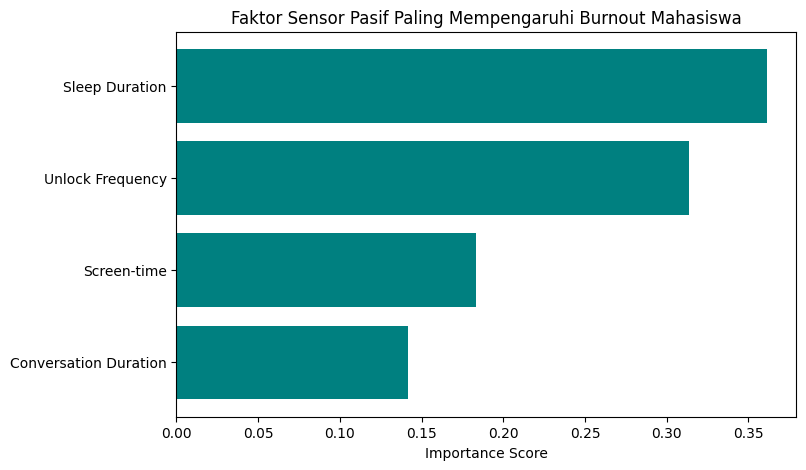

In [ ]:
importances = rf.feature_importances_
df_imp = pd.DataFrame({
    'Sensor': ['Screen-time', 'Unlock Frequency', 'Sleep Duration', 'Conversation Duration'],
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("=== FEATURE IMPORTANCE ===")
print(df_imp.to_string(index=False))

# Plot
plt.figure(figsize=(8, 5))
plt.barh(df_imp['Sensor'], df_imp['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Faktor Sensor Pasif Paling Mempengaruhi Burnout Mahasiswa')
plt.gca().invert_yaxis()
plt.show()
